# NeuralQ S2SR — Small-Batch Classification + Index Time Series (1 m, REAL)

Maximum-information deep dive on one **1024×1024 px (1 km²) batch** cut from the real seam-free series (`SidiBouzid-fields-2024`, 9.56E 35.06N). The window (row 3072, col 768) was auto-selected for highest NDVI variance + green-parcel density, so one chip holds fallow, orchards, and irrigated parcels.

**Pipeline:**
1. Load the batch cube: 15 indices × 4 dates (Mar→Jun 2024) from the real `MS.tif` SR products.
2. Index time series: per-index mean/median/std/p10–p90 + per-class and per-parcel series.
3. Classification suite per pixel: NDVI vigor (5 bins) × date, health zones, rule-tree crop types, KMeans temporal clusters (k=6), ΔNDVI change classes, water/bare frequency, per-pixel linear slope.
4. Parcel segmentation (connected components on peak-greenness mask) + per-parcel fact table.
5. Batch report: `BATCH_REPORT.md`, `batch_timeseries.csv`, `parcel_table.csv`, transition matrix, 6 GeoTIFF maps + PNGs.

**Caveats:** spectral-only archetypes, no ground truth; thresholds are Sidi Bouzid defaults; KMeans labels are data-driven clusters ordered by NDVI, not crop names. The batch sits inside 4120×4120 validated runs (anchor MAE 99–303 DN, seam ratio ≈1.0).

## 0. Setup

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
for _up in [ROOT, *ROOT.parents]:  # walk up: works from notebooks/<track>/ too
    if (_up / 'scripts' / 'run_location.py').exists():
        ROOT = _up
        break
print('ROOT', ROOT)
sys.path.insert(0, str(ROOT / 'scripts'))
import numpy as np
import matplotlib
# inline backend: every figure renders INSIDE its cell output, no external viewer needed
%matplotlib inline
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
print('numpy', np.__version__, '| rasterio', rasterio.__version__)
try:
    import sklearn; print('sklearn', sklearn.__version__); HAS_SK = True
except Exception: HAS_SK = False; print('no sklearn — KMeans skipped')
try:
    import scipy; print('scipy', scipy.__version__); HAS_SP = True
except Exception: HAS_SP = False; print('no scipy — parcels skipped')

ROOT /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core


numpy 2.5.2 | rasterio 1.5.0


sklearn 1.9.0
scipy 1.18.0


## 1. Batch config — fixed window on the validated real series

In [2]:
SERIES = ROOT / 'outputs' / 'TN' / 'crop-timeseries' / 'SidiBouzid-fields-2024'
DATES = ['2024-02-07','2024-03-15','2024-04-02','2024-04-20','2024-05-08','2024-05-25','2024-06-20','2024-07-15']
BROW, BCOL, BSZ = 3072, 768, 1024  # auto-selected: max NDVI variance + green density
BATCH = SERIES / f'batch_r{BROW}_c{BCOL}'
BATCH.mkdir(parents=True, exist_ok=True)
BAND_ORDER = ('B02','B03','B04','B08','B05','B06','B07','B11','B12','B8A')
VEG = ['ndvi','gndvi','ndre','evi2','savi','mtci']
WATER = ['ndwi','mndwi','ndmi','awei']
SOIL = ['bsi','ndbi','ndti']
BURN = ['nbr','nbr2']
ALL_IDX = VEG + WATER + SOIL + BURN
CAT_OF = {n: 'vegetation' for n in VEG} | {n: 'water' for n in WATER} | {n: 'soil_urban' for n in SOIL} | {n: 'burn' for n in BURN}
assert all((SERIES / d / 'MS.tif').exists() for d in DATES), 'real series missing — run the 4 dates first'
print('batch', BATCH, f'{BSZ}x{BSZ} @ row {BROW} col {BCOL}')

batch /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/crop-timeseries/SidiBouzid-fields-2024/batch_r3072_c768 1024x1024 @ row 3072 col 768


## 2. Load the batch cube (15 indices × 4 dates)

In [3]:
import csv
cube, CREF = {}, {}
for date in DATES:
    cube[date] = {}
    for name in ALL_IDX:
        p = SERIES / date / 'indices' / CAT_OF[name] / f'{name}.tiff'
        with rasterio.open(p) as src:
            win = Window(BCOL, BROW, BSZ, BSZ)
            arr = src.read(1, window=win).astype(np.float32)
            if date == DATES[0] and name == 'ndvi':
                CREF = {'profile': src.profile.copy(), 'transform': src.window_transform(win), 'crs': src.crs}
        cube[date][name] = arr
print('cube:', len(DATES), 'dates x', len(ALL_IDX), 'indices x', cube[DATES[0]]['ndvi'].shape)
rows = []
for date in DATES:
    for name in ALL_IDX:
        v = cube[date][name]; vv = v[np.isfinite(v)]
        rows.append({'date': date, 'index': name, 'category': CAT_OF[name], 'mean': float(np.mean(vv)),
            'median': float(np.median(vv)), 'std': float(np.std(vv)),
            'p10': float(np.percentile(vv, 10)), 'p90': float(np.percentile(vv, 90)),
            'frac_valid': float(vv.size / v.size)})
with open(BATCH / 'batch_timeseries.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
for r in rows:
    if r['index'] in ('ndvi', 'ndmi', 'bsi', 'mtci'): print(f"{r['date']} {r['index']:5s} mean {r['mean']:+.3f} std {r['std']:.3f} p10 {r['p10']:+.3f} p90 {r['p90']:+.3f}")

/tmp/ipykernel_33749/2940239507.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1, window=win).astype(np.float32)


cube: 8 dates x 15 indices x (1024, 1024)


2024-02-07 ndvi  mean +0.403 std 0.209 p10 +0.168 p90 +0.740
2024-02-07 mtci  mean +1.614 std 0.793 p10 +0.698 p90 +2.690
2024-02-07 ndmi  mean +0.024 std 0.138 p10 -0.113 p90 +0.235
2024-02-07 bsi   mean +0.060 std 0.145 p10 -0.161 p90 +0.193
2024-03-15 ndvi  mean +0.356 std 0.209 p10 +0.160 p90 +0.744
2024-03-15 mtci  mean +1.480 std 0.894 p10 +0.575 p90 +2.879
2024-03-15 ndmi  mean +0.013 std 0.153 p10 -0.122 p90 +0.277
2024-03-15 bsi   mean +0.068 std 0.158 p10 -0.208 p90 +0.199
2024-04-02 ndvi  mean +0.335 std 0.191 p10 +0.159 p90 +0.681
2024-04-02 mtci  mean +1.488 std 0.870 p10 +0.613 p90 +2.806
2024-04-02 ndmi  mean +0.007 std 0.143 p10 -0.116 p90 +0.255
2024-04-02 bsi   mean +0.074 std 0.142 p10 -0.171 p90 +0.191
2024-04-20 ndvi  mean +0.303 std 0.161 p10 +0.153 p90 +0.581
2024-04-20 mtci  mean +1.304 std 0.691 p10 +0.562 p90 +2.358
2024-04-20 ndmi  mean -0.003 std 0.105 p10 -0.093 p90 +0.175
2024-04-20 bsi   mean +0.095 std 0.104 p10 -0.079 p90 +0.180
2024-05-08 ndvi  mean +0

## 3. Index time series plots (batch means + p10–p90 bands)

wrote batch_timelines.png


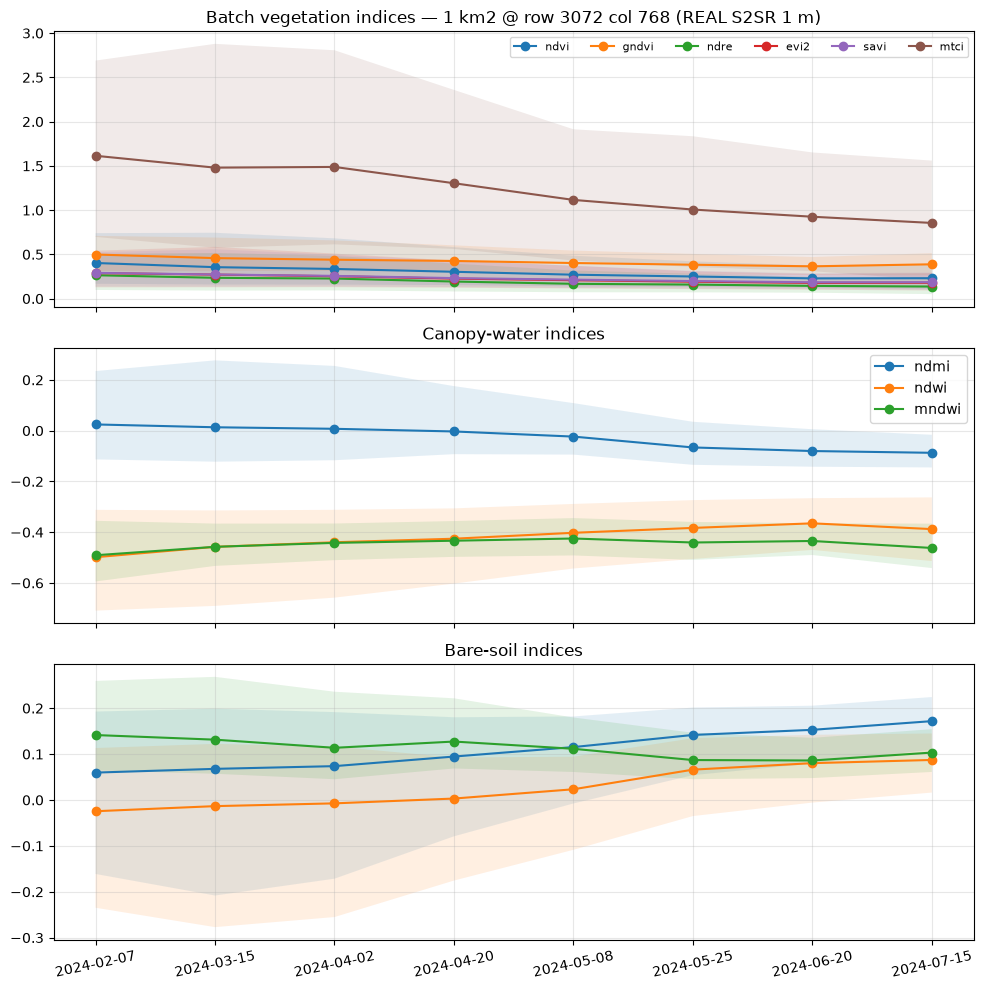

In [4]:
def _s(name, key='mean'): return [next(r[key] for r in rows if r['date'] == d and r['index'] == name) for d in DATES]
x = np.arange(len(DATES))
fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for name in VEG:
    ax[0].plot(x, _s(name), marker='o', label=name)
    ax[0].fill_between(x, _s(name, 'p10'), _s(name, 'p90'), alpha=0.12)
ax[0].set_title(f'Batch vegetation indices — 1 km2 @ row {BROW} col {BCOL} (REAL S2SR 1 m)'); ax[0].legend(ncol=6, fontsize=8); ax[0].grid(alpha=0.3)
for name in ['ndmi', 'ndwi', 'mndwi']:
    ax[1].plot(x, _s(name), marker='o', label=name)
    ax[1].fill_between(x, _s(name, 'p10'), _s(name, 'p90'), alpha=0.12)
ax[1].set_title('Canopy-water indices'); ax[1].legend(); ax[1].grid(alpha=0.3)
for name in SOIL:
    ax[2].plot(x, _s(name), marker='o', label=name)
    ax[2].fill_between(x, _s(name, 'p10'), _s(name, 'p90'), alpha=0.12)
ax[2].set_title('Bare-soil indices'); ax[2].set_xticks(x, DATES, rotation=12); ax[2].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(BATCH / 'batch_timelines.png', dpi=130); print('wrote batch_timelines.png')
plt.show()  # render inline in the cell output


## 4. Classification suite — vigor, health, crop types, KMeans, change, frequency, slope

In [5]:
st = np.stack([cube[d]['ndvi'] for d in DATES]).astype(np.float32)  # T,H,W
ndvi_mean = np.nanmean(st, axis=0); ndvi_max = np.nanmax(st, axis=0); ndvi_min = np.nanmin(st, axis=0)
ndvi_amp = ndvi_max - ndvi_min; late_slope = st[-1] - st[-2]; overall = st[-1] - st[0]
tt = np.arange(len(DATES), dtype=np.float32)
slope = np.full(st.shape[1:], np.nan, np.float32)
m = np.isfinite(st).all(axis=0)
X = np.stack([tt] * int(m.sum()), axis=0)
Y = st[:, m].T
b = ((X - X.mean(1, keepdims=True)) * (Y - Y.mean(1, keepdims=True))).sum(1) / (((X - X.mean(1, keepdims=True)) ** 2).sum(1) + 1e-9)
slope[m] = b.astype(np.float32)
print(f'slope/date: mean {np.nanmean(slope):+.4f} | senescing(<-0.05) {np.nanmean(slope < -0.05):.1%} | greening(>0.05) {np.nanmean(slope > 0.05):.1%}')
VBINS = [-2.0, 0.20, 0.35, 0.50, 0.65, 2.0]; VNAMES = ['bare', 'sparse', 'moderate', 'vigorous', 'dense']
vigor = {d: np.clip(np.digitize(cube[d]['ndvi'], VBINS) - 1, 0, 4).astype(np.int8) for d in DATES}
for d in DATES:
    u, c = np.unique(vigor[d], return_counts=True)
    print(d, {VNAMES[int(i)]: round(float(n) / vigor[d].size, 3) for i, n in zip(u, c)})
trans = np.zeros((5, 5), int)
a, b2 = vigor[DATES[0]].ravel(), vigor[DATES[-1]].ravel()
for i, j in zip(a, b2): trans[int(i), int(j)] += 1
print('vigor transition Mar->Jun (rows Mar, cols Jun):')
print('       ' + ' '.join(f'{n:>8s}' for n in VNAMES))
for i, n in enumerate(VNAMES): print(f'{n:>7s} ' + ' '.join(f'{v:8d}' for v in trans[i]))
def _c01(a): return np.clip(a, 0, 1)
C = cube[DATES[-1]]
h = (0.35 * _c01((C['ndvi'] + 1) / 2) + 0.25 * _c01((C['ndre'] + 1) / 2) + 0.15 * _c01(C['mtci'] / 6.0) + 0.15 * _c01((C['ndmi'] + 1) / 2) - 0.10 * _c01((C['bsi'] + 1) / 2)).astype(np.float32)
h[~np.isfinite(C['ndvi'])] = np.nan
is_water = C['mndwi'] > 0.25; is_bare = (~is_water) & ((C['ndvi'] < 0.20) | (C['bsi'] > 0.12))
zone = np.full(h.shape, 3, np.int8); zone[h >= 0.62] = 5; zone[(h >= 0.50) & (h < 0.62)] = 4
zone[(h < 0.50) & (h >= 0.38)] = 3; zone[h < 0.38] = 2; zone[is_bare] = 1; zone[is_water] = 0
ZN = {-1: 'nodata', 0: 'water', 1: 'bare/fallow', 2: 'poor', 3: 'stressed', 4: 'moderate', 5: 'healthy'}
mtci_m = np.nanmean(np.stack([cube[d]['mtci'] for d in DATES]), axis=0)
ndre_m = np.nanmean(np.stack([cube[d]['ndre'] for d in DATES]), axis=0)
ndmi_m = np.nanmean(np.stack([cube[d]['ndmi'] for d in DATES]), axis=0)
bsi_m = np.nanmean(np.stack([cube[d]['bsi'] for d in DATES]), axis=0)
mndwi_m = np.nanmean(np.stack([cube[d]['mndwi'] for d in DATES]), axis=0)
cls = np.full(ndvi_mean.shape, 4, np.int8)
cls[mndwi_m > 0.25] = 0
cls[(mndwi_m <= 0.25) & (ndvi_max < 0.35) & (bsi_m > 0.02)] = 1
cls[(mndwi_m <= 0.25) & (ndvi_mean > 0.55) & (mtci_m > 1.8)] = 2
cls[(mndwi_m <= 0.25) & (ndvi_amp > 0.22) & (late_slope < -0.08) & (ndvi_mean <= 0.62)] = 3
cls[(mndwi_m <= 0.25) & (ndvi_mean >= 0.32) & (ndvi_mean <= 0.52) & (bsi_m > -0.05) & (cls == 4)] = 5
cls[~np.isfinite(ndvi_mean)] = -1
CN = {-1: 'nodata', 0: 'water', 1: 'fallow/bare', 2: 'vegetable/high-chl', 3: 'cereal-like', 4: 'mixed/other', 5: 'orchard/sparse'}
chg = np.full(st.shape[1:], 4, np.int8)  # 0 greening,1 senescing,2 stable-green,3 stable-bare,4 mixed
chg[(overall > 0.08)] = 0; chg[(overall < -0.08)] = 1
chg[(np.abs(overall) <= 0.08) & (ndvi_mean > 0.45)] = 2; chg[(np.abs(overall) <= 0.08) & (ndvi_mean <= 0.45)] = 3
CHN = {0: 'greening', 1: 'senescing', 2: 'stable-green', 3: 'stable-bare', 4: 'mixed'}
water_freq = np.nanmean(np.stack([cube[d]['mndwi'] > 0.25 for d in DATES]), axis=0).astype(np.float32)
bare_freq = np.nanmean(np.stack([(cube[d]['ndvi'] < 0.20) | (cube[d]['bsi'] > 0.12) for d in DATES]), axis=0).astype(np.float32)
km = np.full(st.shape[1:], -1, np.int8); km_note = 'skipped (no sklearn)'
if HAS_SK:
    from sklearn.cluster import KMeans
    F = np.stack([ndvi_mean, ndvi_amp, late_slope, np.clip(mtci_m, -2, 6), ndre_m, ndmi_m, bsi_m], axis=-1)
    mm = np.isfinite(F).all(-1)
    Z = F[mm].reshape(-1, 7); Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-6)
    lab = KMeans(n_clusters=6, n_init=10, random_state=0).fit_predict(Z)
    order = np.argsort([Z[lab == k, 0].mean() for k in range(6)])
    remap = np.empty(6, int); remap[order] = np.arange(6)
    km[mm] = remap[lab].astype(np.int8)
    km_note = 'KMeans k=6 ok, labels 0..5 ordered by NDVI'
    print(km_note)
for name, arr, labels in [('zone', zone, ZN), ('crop-type', cls, CN), ('change', chg, CHN)]:
    v, c = np.unique(arr[arr >= 0], return_counts=True)
    print(name, {labels[int(i)]: round(float(n) / (arr >= 0).sum(), 3) for i, n in zip(v, c)})

slope/date: mean -0.0253 | senescing(<-0.05) 15.4% | greening(>0.05) 0.9%
2024-02-07 {'bare': 0.158, 'sparse': 0.326, 'moderate': 0.247, 'vigorous': 0.118, 'dense': 0.151}
2024-03-15 {'bare': 0.232, 'sparse': 0.419, 'moderate': 0.143, 'vigorous': 0.067, 'dense': 0.139}
2024-04-02 {'bare': 0.266, 'sparse': 0.416, 'moderate': 0.123, 'vigorous': 0.078, 'dense': 0.116}
2024-04-20 {'bare': 0.33, 'sparse': 0.385, 'moderate': 0.13, 'vigorous': 0.103, 'dense': 0.052}
2024-05-08 {'bare': 0.374, 'sparse': 0.413, 'moderate': 0.123, 'vigorous': 0.076, 'dense': 0.014}
2024-05-25 {'bare': 0.444, 'sparse': 0.389, 'moderate': 0.106, 'vigorous': 0.046, 'dense': 0.015}
2024-06-20 {'bare': 0.503, 'sparse': 0.378, 'moderate': 0.084, 'vigorous': 0.03, 'dense': 0.006}
2024-07-15 {'bare': 0.505, 'sparse': 0.365, 'moderate': 0.079, 'vigorous': 0.035, 'dense': 0.016}


vigor transition Mar->Jun (rows Mar, cols Jun):
           bare   sparse moderate vigorous    dense
   bare   149655    10454     2739     1938      849
 sparse   199799   122282    12168     5703     2295
moderate    93453   134887    22655     5025     2616
vigorous    29240    58683    24686     8814     2192
  dense    57530    56544    20839    15048     8482


KMeans k=6 ok, labels 0..5 ordered by NDVI
zone {'bare/fallow': np.float64(0.885), 'poor': np.float64(0.0), 'stressed': np.float64(0.064), 'moderate': np.float64(0.049), 'healthy': np.float64(0.001)}
crop-type {'fallow/bare': np.float64(0.397), 'vegetable/high-chl': np.float64(0.037), 'cereal-like': np.float64(0.029), 'mixed/other': np.float64(0.26), 'orchard/sparse': np.float64(0.278)}
change {'greening': np.float64(0.036), 'senescing': np.float64(0.633), 'stable-green': np.float64(0.016), 'stable-bare': np.float64(0.316)}


## 5. Classification maps

wrote batch_classmaps.png


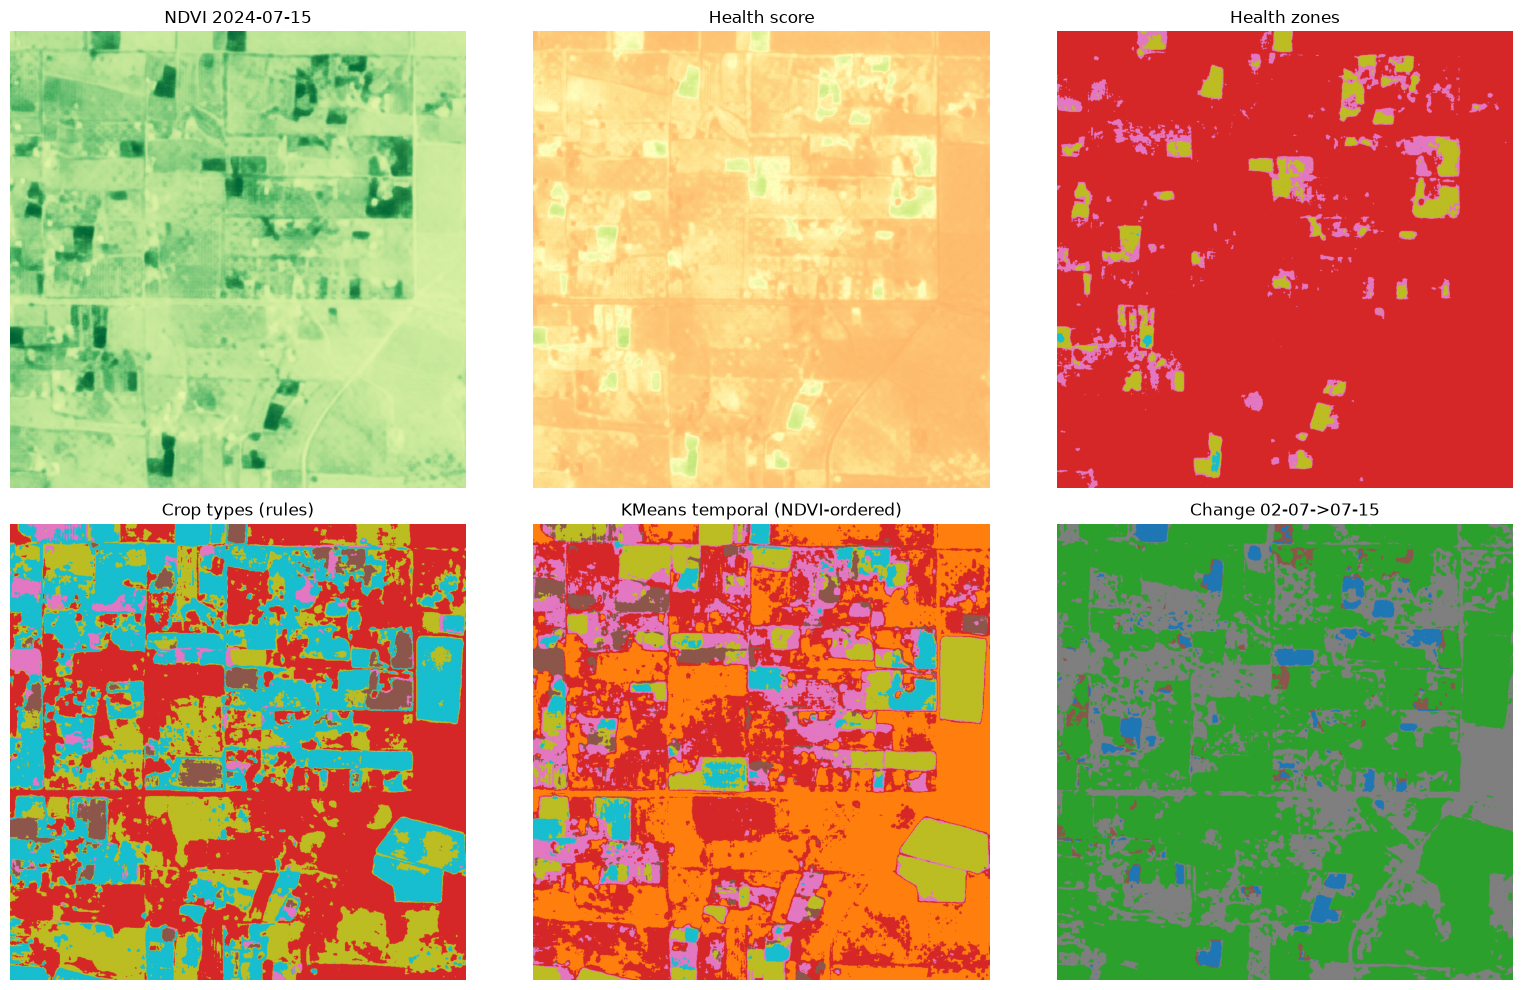

wrote batch_change.png


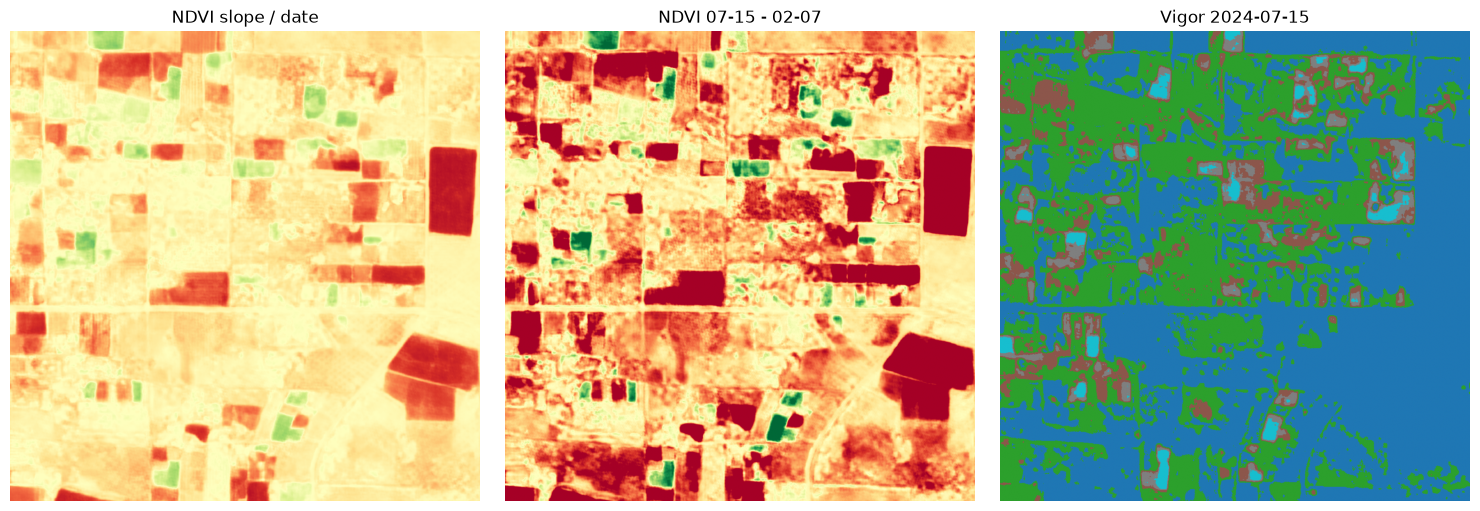

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(16, 10))
ax[0][0].imshow(np.clip(cube[DATES[-1]]['ndvi'], -1, 1), vmin=-0.2, vmax=0.9, cmap='YlGn'); ax[0][0].set_title(f"NDVI {DATES[-1]}")
ax[0][1].imshow(np.clip(h, 0, 1), vmin=0, vmax=1, cmap='RdYlGn'); ax[0][1].set_title('Health score')
ax[0][2].imshow(zone, vmin=-1, vmax=5, cmap='tab10'); ax[0][2].set_title('Health zones')
ax[1][0].imshow(cls, vmin=-1, vmax=5, cmap='tab10'); ax[1][0].set_title('Crop types (rules)')
ax[1][1].imshow(km, vmin=-1, vmax=5, cmap='tab10'); ax[1][1].set_title('KMeans temporal (NDVI-ordered)')
ax[1][2].imshow(chg, vmin=0, vmax=4, cmap='tab10'); ax[1][2].set_title(f'Change {DATES[0][5:]}->{DATES[-1][5:]}')
for a in ax.ravel(): a.axis('off')
fig.tight_layout(); fig.savefig(BATCH / 'batch_classmaps.png', dpi=130); print('wrote batch_classmaps.png')
plt.show()  # render inline in the cell output
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(slope, vmin=-0.15, vmax=0.15, cmap='RdYlGn'); ax[0].set_title('NDVI slope / date'); ax[0].axis('off')
ax[1].imshow(overall, vmin=-0.4, vmax=0.4, cmap='RdYlGn'); ax[1].set_title(f'NDVI {DATES[-1][5:]} - {DATES[0][5:]}'); ax[1].axis('off')
ax[2].imshow(vigor[DATES[-1]], vmin=0, vmax=4, cmap='tab10'); ax[2].set_title(f"Vigor {DATES[-1]}"); ax[2].axis('off')
fig.tight_layout(); fig.savefig(BATCH / 'batch_change.png', dpi=130); print('wrote batch_change.png')
plt.show()  # render inline in the cell output


## 6. Parcels — segmentation on peak greenness + per-parcel fact table

33 parcels >=400 m2 (from 254 raw components)
wrote parcel_table.csv (33 parcels), largest 273223 m2


wrote parcels.png


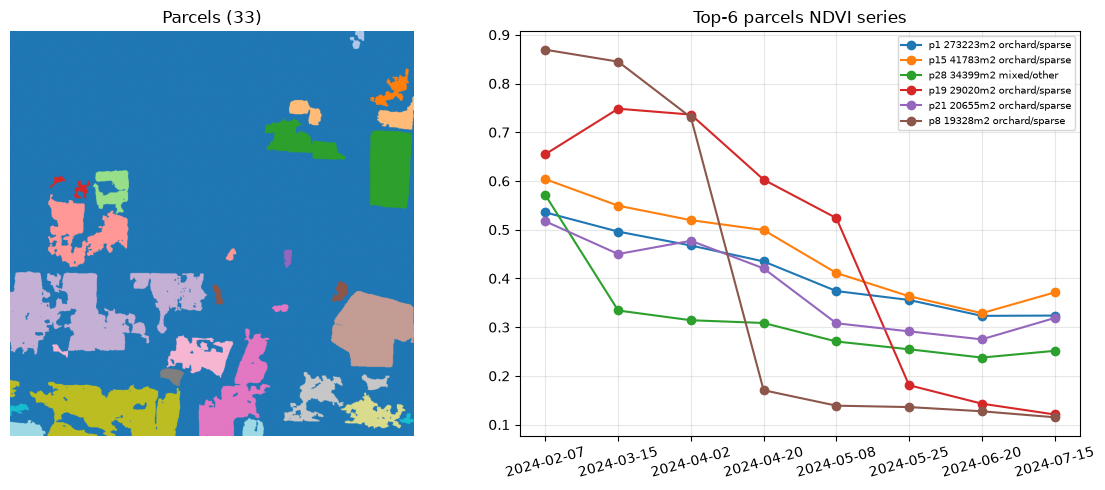

In [7]:
parcels, PNOTE = None, ''
if HAS_SP:
    from scipy import ndimage
    seed = (ndvi_max > 0.40).astype(np.uint8)
    seed = ndimage.binary_opening(seed, structure=np.ones((3, 3)))
    parcels, npar = ndimage.label(seed, structure=np.ones((3, 3)))
    sizes = np.bincount(parcels.ravel())[1:]
    keep = np.where(sizes >= 400)[0] + 1  # >=400 m2
    remap = np.zeros(parcels.max() + 1, int); remap[keep] = np.arange(1, len(keep) + 1)
    parcels = remap[parcels].astype(np.int32)
    PNOTE = f'{len(keep)} parcels >=400 m2 (from {npar} raw components)'
    print(PNOTE)
else:
    PNOTE = 'skipped (no scipy)'
    print(PNOTE)
if parcels is not None and parcels.max() > 0:
    import csv as _csv
    prows = []
    for pid in range(1, int(parcels.max()) + 1):
        mk = parcels == pid
        area = int(mk.sum())
        series = [float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES]
        crow = {'parcel': pid, 'area_m2': area,
                **{f'ndvi_{d}': round(v, 4) for d, v in zip(DATES, series)},
                'ndvi_amp': round(float(np.nanmax(series) - np.nanmin(series)), 4),
                'ndvi_slope': round(float(series[-1] - series[-2]), 4),
                'health_mean': round(float(np.nanmean(h[mk])), 4),
                'dom_class': CN[int(np.bincount(cls[mk & (cls >= 0)]).argmax())] if (cls[mk] >= 0).any() else 'nodata',
                'bare_frac': round(float(np.nanmean(bare_freq[mk])), 3)}
        prows.append(crow)
    prows.sort(key=lambda r: -r['area_m2'])
    with open(BATCH / 'parcel_table.csv', 'w', newline='') as f:
        w = _csv.DictWriter(f, fieldnames=list(prows[0].keys())); w.writeheader(); w.writerows(prows)
    print(f"wrote parcel_table.csv ({len(prows)} parcels), largest {prows[0]['area_m2']} m2")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(parcels, cmap='tab20'); ax[0].set_title(f'Parcels ({len(prows)})'); ax[0].axis('off')
    for r in prows[:6]:
        ax[1].plot(DATES, [r[f'ndvi_{d}'] for d in DATES], marker='o', label=f"p{r['parcel']} {r['area_m2']}m2 {r['dom_class']}")
    ax[1].set_title('Top-6 parcels NDVI series'); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3); ax[1].tick_params(axis='x', rotation=15)
    fig.tight_layout(); fig.savefig(BATCH / 'parcels.png', dpi=130); print('wrote parcels.png')
    plt.show()  # render inline in the cell output


## 7. Per-class index series + batch report + GeoTIFF exports

wrote perclass_series.png


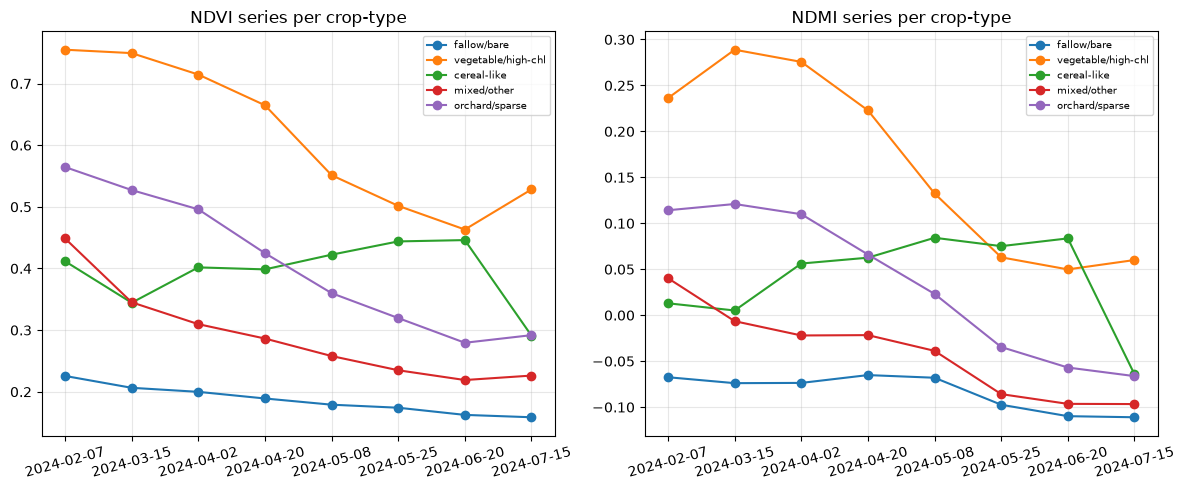

# Batch Report — 1 km2 @ row 3072 col 768 (REAL S2SR 1 m)

Parent series: SidiBouzid-fields-2024 (9.56E 35.06N), dates 2024-02-07 → 2024-03-15 → 2024-04-02 → 2024-04-20 → 2024-05-08 → 2024-05-25 → 2024-06-20 → 2024-07-15

## Batch index timeline (mean)

- ndvi: +0.403 → +0.356 → +0.335 → +0.303 → +0.270 → +0.250 → +0.229 → +0.231
- ndre: +0.264 → +0.235 → +0.227 → +0.193 → +0.167 → +0.159 → +0.144 → +0.137
- mtci: +1.614 → +1.480 → +1.488 → +1.304 → +1.115 → +1.007 → +0.925 → +0.855
- evi2: +0.289 → +0.271 → +0.253 → +0.226 → +0.208 → +0.191 → +0.178 → +0.179
- ndmi: +0.024 → +0.013 → +0.007 → -0.003 → -0.023 → -0.066 → -0.080 → -0.087
- bsi: +0.060 → +0.068 → +0.074 → +0.095 → +0.115 → +0.142 → +0.153 → +0.172
- ndbi: -0.024 → -0.013 → -0.007 → +0.003 → +0.023 → +0.066 → +0.080 → +0.087

## Pixel classifications @ latest (% batch)

...
wrote BATCH_REPORT.md


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for code in sorted(int(v) for v in np.unique(cls[cls >= 0])):
    mk = cls == code
    ax[0].plot(DATES, [float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES], marker='o', label=CN[code])
    ax[1].plot(DATES, [float(np.nanmean(cube[d]['ndmi'][mk])) for d in DATES], marker='o', label=CN[code])
ax[0].set_title('NDVI series per crop-type'); ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3); ax[0].tick_params(axis='x', rotation=15)
ax[1].set_title('NDMI series per crop-type'); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3); ax[1].tick_params(axis='x', rotation=15)
fig.tight_layout(); fig.savefig(BATCH / 'perclass_series.png', dpi=130); print('wrote perclass_series.png')
plt.show()  # render inline in the cell output
def _save(array: np.ndarray, name: str, dtype: str, nodata):
    prof = CREF['profile'].copy()
    prof.update(height=array.shape[0], width=array.shape[1], transform=CREF['transform'], crs=CREF['crs'],
                count=1, dtype=dtype, nodata=nodata, compress='NONE')
    for k in ('blockxsize', 'blockysize', 'tiled', 'compress'): prof.pop(k, None)
    p = BATCH / name
    with rasterio.open(p, 'w', **prof) as dst: dst.write(array.astype(dtype), 1)
    return p
_save(np.where(np.isfinite(h), np.clip(h * 100, 0, 100), 255).astype(np.uint8), 'batch_health.tif', 'uint8', 255)
_save(np.where(cls < 0, 255, cls.astype(np.int16)).astype(np.uint8), 'batch_croptype.tif', 'uint8', 255)
_save(np.where(km < 0, 255, km.astype(np.int16)).astype(np.uint8) if HAS_SK else np.full(h.shape, 255, np.uint8), 'batch_kmeans.tif', 'uint8', 255)
_save(vigor[DATES[-1]].astype(np.uint8), 'batch_vigor.tif', 'uint8', 255)
_save(np.where(np.isfinite(slope), slope, -999).astype(np.float32), 'batch_slope.tif', 'float32', -999.0)
_save(np.where(np.isfinite(overall), overall, -999).astype(np.float32), 'batch_dndvi.tif', 'float32', -999.0)
L = [f'# Batch Report — 1 km2 @ row {BROW} col {BCOL} (REAL S2SR 1 m)', '',
     f"Parent series: SidiBouzid-fields-2024 (9.56E 35.06N), dates {' → '.join(DATES)}", '', '## Batch index timeline (mean)', '']
for nm in ['ndvi', 'ndre', 'mtci', 'evi2', 'ndmi', 'bsi', 'ndbi']:
    L.append(f"- {nm}: " + ' → '.join(f"{next(r['mean'] for r in rows if r['date'] == d and r['index'] == nm):+.3f}" for d in DATES))
L += ['', '## Pixel classifications @ latest (% batch)', '']
for name, arr, lab in [('health-zone', zone, ZN), ('crop-type', cls, CN), ('change', chg, CHN)]:
    v, c = np.unique(arr[arr >= 0], return_counts=True)
    L.append(f"- {name}: " + ', '.join(f"{lab[int(i)]} {100 * float(n) / (arr >= 0).sum():.1f}%" for i, n in zip(v, c)))
L += ['', '## Vigor transition Mar→Jun', '']
L.append('rows=Mar class, cols=Jun class: ' + ', '.join(VNAMES))
for i, n in enumerate(VNAMES): L.append(f"- {n}: " + ', '.join(f"{VNAMES[j]} {v}" for j, v in enumerate(trans[i])))
L += ['', f'## Parcels: {PNOTE}', f'## Clustering: {km_note}',
      f"- senescing {np.nanmean(slope < -0.05):.1%}, greening {np.nanmean(slope > 0.05):.1%}, water-ever {np.nanmean(water_freq > 0):.1%}, bare-always {np.nanmean(bare_freq == 1):.1%}", '',
      '## Limits', '- Spectral archetypes only; re-tune thresholds with field data before action.', '', '## Files',
      '- batch_timeseries.csv, parcel_table.csv, batch_classmaps.png, batch_change.png, parcels.png, perclass_series.png',
      '- batch_health/croptype/kmeans/vigor/slope/dndvi.tif (GeoTIFF, same grid as source indices)']
(BATCH / 'BATCH_REPORT.md').write_text('\n'.join(L) + '\n')
print('\n'.join(L[:16])); print('...'); print('wrote BATCH_REPORT.md')

## 7b. Per-crop health status — health *within* each crop type

Same health formula scored per date, then aggregated inside each rule-tree crop mask: mean health series, trend, zone mix, and a status label per crop. Fallow/water get non-crop labels instead of a health grade.

fallow/bare          area  415844 health 0.394 → 0.385 → 0.385 → 0.380 → 0.375 → 0.370 → 0.363 → 0.359 trend -0.035 zones bare/fallow 99.1%; stressed 0.9%; poor 0.0% => Fallow — no active crop
vegetable/high-chl   area   38504 health 0.624 → 0.632 → 0.625 → 0.590 → 0.535 → 0.512 → 0.499 → 0.514 trend -0.110 zones moderate 58.9%; bare/fallow 22.1%; stressed 17.2%; healthy 1.8% => Watch


cereal-like          area   30023 health 0.468 → 0.446 → 0.477 → 0.476 → 0.484 → 0.491 → 0.493 → 0.414 trend -0.055 zones bare/fallow 76.4%; stressed 19.5%; moderate 4.1% => Stressed
mixed/other          area  272824 health 0.486 → 0.445 → 0.434 → 0.421 → 0.408 → 0.394 → 0.387 → 0.387 trend -0.099 zones bare/fallow 92.9%; stressed 4.6%; moderate 2.4%; healthy 0.0% => Critical
orchard/sparse       area  291381 health 0.535 → 0.527 → 0.518 → 0.483 → 0.451 → 0.431 → 0.414 → 0.413 trend -0.122 zones bare/fallow 79.4%; stressed 13.0%; moderate 7.3%; healthy 0.2% => Stressed
wrote crop_health.csv


wrote crop_health.png


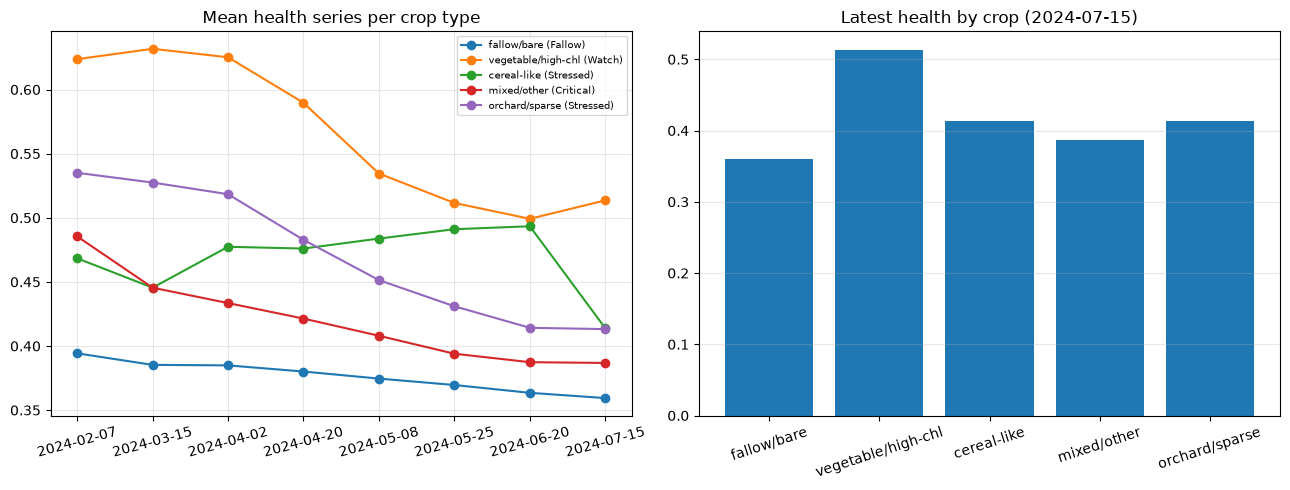

BATCH_REPORT.md extended


In [9]:
def _health_of(D):
    C = cube[D]
    def _c01(a): return np.clip(a, 0, 1)
    q = (0.35*_c01((C['ndvi']+1)/2)+0.25*_c01((C['ndre']+1)/2)+0.15*_c01(C['mtci']/6.0)+0.15*_c01((C['ndmi']+1)/2)-0.10*_c01((C['bsi']+1)/2)).astype(np.float32)
    q[~np.isfinite(C['ndvi'])] = np.nan
    return q
H = {d: _health_of(d) for d in DATES}
import csv as _csv
chrows = []
for code in sorted(int(v) for v in np.unique(cls[cls >= 0])):
    mk = (cls == code)
    hser = [float(np.nanmean(H[d][mk])) for d in DATES]
    nser = [float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES]
    hm = hser[-1]; trend = hser[-1] - hser[0]
    z = zone[mk]; zv, zc = np.unique(z[z >= 0], return_counts=True)
    zd = {ZN[int(i)]: float(n) / (z >= 0).sum() for i, n in zip(zv, zc)}
    sf = zd.get('stressed', 0) + zd.get('poor', 0)
    nm = CN[code]
    if nm in ('fallow/bare',): status = 'Fallow — no active crop'
    elif nm in ('water',): status = 'Water — non-crop'
    elif hm >= 0.55 and sf < 0.25: status = 'Healthy'
    elif hm >= 0.48: status = 'Watch'
    elif hm >= 0.40: status = 'Stressed'
    else: status = 'Critical'
    chrows.append({'crop': nm, 'area_px': int(mk.sum()), 'area_m2': int(mk.sum()),
        **{f'health_{d}': round(v, 4) for d, v in zip(DATES, hser)},
        **{f'ndvi_{d}': round(v, 4) for d, v in zip(DATES, nser)},
        'health_trend': round(trend, 4), 'stressed_poor_frac': round(sf, 4),
        'zones': '; '.join(f'{k} {100*v:.1f}%' for k, v in sorted(zd.items(), key=lambda kv: -kv[1])),
        'status': status})
    print(f"{nm:20s} area {mk.sum():7d} health {' → '.join(f'{v:.3f}' for v in hser)} trend {trend:+.3f} zones {chrows[-1]['zones']} => {status}")
with open(BATCH / 'crop_health.csv', 'w', newline='') as f:
    w = _csv.DictWriter(f, fieldnames=list(chrows[0].keys())); w.writeheader(); w.writerows(chrows)
print('wrote crop_health.csv')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for r in chrows:
    if r['crop'] in ('water',): continue
    ax[0].plot(DATES, [r[f'health_{d}'] for d in DATES], marker='o', label=f"{r['crop']} ({r['status'].split(' —')[0]})")
ax[0].set_title('Mean health series per crop type'); ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3); ax[0].tick_params(axis='x', rotation=15)
labels = [r['crop'] for r in chrows if r['crop'] != 'water']
ax[1].bar(labels, [next(r[f'health_{DATES[-1]}'] for r in chrows if r['crop'] == l) for l in labels])
ax[1].set_title(f"Latest health by crop ({DATES[-1]})"); ax[1].tick_params(axis='x', rotation=18); ax[1].grid(alpha=0.3, axis='y')
fig.tight_layout(); fig.savefig(BATCH / 'crop_health.png', dpi=130); print('wrote crop_health.png')
plt.show()  # render inline in the cell output
RL = (BATCH / 'BATCH_REPORT.md').read_text().splitlines()
RL += ['', '## Crop x health status', '']
RL.append('| crop | area m2 | health Mar→Jun | trend | stressed+poor | status |')
RL.append('| --- | ---: | --- | ---: | ---: | --- |')
for r in chrows:
    RL.append(f"| {r['crop']} | {r['area_m2']} | " + ' → '.join(f"{r[f'health_{d}']:.3f}" for d in DATES) + f" | {r['health_trend']:+.3f} | {100*r['stressed_poor_frac']:.1f}% | {r['status']} |")
RL.append('')
(BATCH / 'BATCH_REPORT.md').write_text('\n'.join(RL) + '\n')
print('BATCH_REPORT.md extended')


## 8. Interactive explorers — inspect every result INSIDE the notebook

No external viewer needed: pick any TIFF (MS band, TCI, index, or product map), stretch, and render inline. Widgets are live in JupyterLab; under headless execution each explorer still prints its default view as a static inline figure.

Dropdown(description='Layer:', index=120, options=('KMeans', 'MS:B02 @ 2024-07-15', 'MS:B03 @ 2024-07-15', 'MS…

IntRangeSlider(value=(2, 98), description='Stretch %:')

Dropdown(description='Colormap:', options=('YlGn', 'RdYlGn', 'viridis', 'plasma', 'coolwarm'), value='YlGn')

Output()

--- static default view (embedded for headless/nbviewer) ---


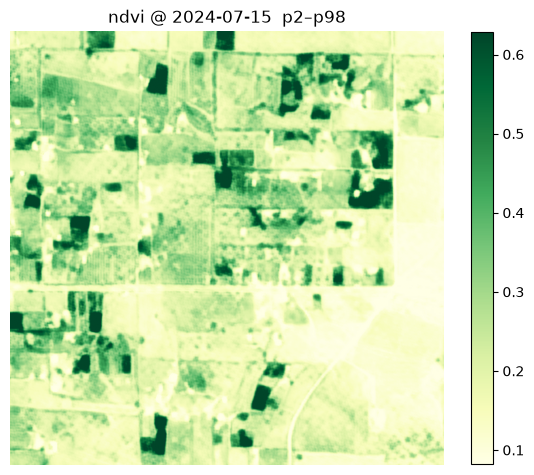

ndvi @ 2024-07-15: shape (1024, 1024) valid 100.0% mean +0.2306 p5 +0.0952 p95 +0.5017


In [10]:
import warnings; warnings.filterwarnings('ignore')
LAYERS = {}
for _d in DATES:
    for _n in ALL_IDX: LAYERS[f'{_n} @ {_d}'] = ('index', _d, _n)
for _b in BAND_ORDER: LAYERS[f'MS:{_b} @ {DATES[-1]}'] = ('msband', DATES[-1], _b)
LAYERS['TCI (visual)'] = ('tci', DATES[-1], None)
LAYERS['health score'] = ('map', None, 'health'); LAYERS['health zones'] = ('map', None, 'zone')
LAYERS['crop types'] = ('map', None, 'cls'); LAYERS['KMeans'] = ('map', None, 'km')
LAYERS['NDVI slope'] = ('map', None, 'slope'); LAYERS[f'dNDVI {DATES[-1][5:]}-{DATES[0][5:]}'] = ('map', None, 'overall')
def _get_layer(key):
    kind, d, n = LAYERS[key]
    Hh, Ww = BSZ, BSZ
    if kind == 'index':
        return cube[d][n].astype(float), 'float'
    if kind == 'msband':
        import rasterio as _r
        from rasterio.windows import Window as _W
        with _r.open(SERIES / d / 'MS.tif') as s:
            return s.read(BAND_ORDER.index(n) + 1, window=_W(BCOL, BROW, BSZ, BSZ)).astype(float), 'dn'
    if kind == 'tci':
        import rasterio as _r
        from rasterio.windows import Window as _W
        with _r.open(SERIES / d / 'TCI.tif') as s:
            return np.moveaxis(s.read(window=_W(BCOL, BROW, BSZ, BSZ), out_shape=(3, 512, 512)), 0, -1), 'rgb'
    return {'health': h, 'zone': zone, 'cls': cls, 'km': km, 'slope': slope, 'overall': overall}[n].astype(float), 'map'
def _show_layer(key, lo=2, hi=98, cmap='YlGn'):
    a, kind = _get_layer(key)
    fig, ax = plt.subplots(figsize=(7, 7))
    if kind == 'rgb': ax.imshow(np.clip(a / 255, 0, 1)); ax.set_title(key)
    elif kind == 'dn':
        v = a[np.isfinite(a)]; l, u = np.percentile(v, [lo, hi])
        ax.imshow(np.clip((a - l) / max(u - l, 1e-9), 0, 1), cmap='gray'); ax.set_title(f'{key}  p{lo}–p{hi} stretch')
    elif key in ('health zones', 'crop types', 'KMeans'):
        ax.imshow(a, vmin=-1, vmax=5, cmap='tab10'); ax.set_title(key)
    else:
        v = a[np.isfinite(a)]; l, u = np.percentile(v, [lo, hi])
        im = ax.imshow(a, vmin=l, vmax=u, cmap=cmap); ax.set_title(f'{key}  p{lo}–p{hi}'); plt.colorbar(im, ax=ax, shrink=0.8)
    ax.axis('off');
    plt.show()
    a2 = a if a.ndim == 2 else a[:, :, 0]
    vv = a2[np.isfinite(a2)]
    print(f'{key}: shape {a.shape} valid {vv.size / a2.size:.1%} mean {np.mean(vv):+.4f} p5 {np.percentile(vv, 5):+.4f} p95 {np.percentile(vv, 95):+.4f}')
try:
    import ipywidgets as widgets
    from IPython.display import display
    _w_layer = widgets.Dropdown(options=sorted(LAYERS), value=f'ndvi @ {DATES[-1]}', description='Layer:')
    _w_str = widgets.IntRangeSlider(value=[2, 98], min=0, max=100, description='Stretch %:')
    _w_cmap = widgets.Dropdown(options=['YlGn', 'RdYlGn', 'viridis', 'plasma', 'coolwarm'], value='YlGn', description='Colormap:')
    _w_out = widgets.Output()
    def _upd(*a):
        _w_out.clear_output(wait=True)
        with _w_out: _show_layer(_w_layer.value, *_w_str.value, _w_cmap.value)
    for _w in (_w_layer, _w_str, _w_cmap): _w.observe(_upd, 'value')
    display(_w_layer, _w_str, _w_cmap, _w_out)
    _upd()
except Exception as e:
    print('widgets unavailable, static default view:', e)
    _show_layer(f'ndvi @ {DATES[-1]}')
print('--- static default view (embedded for headless/nbviewer) ---')
_show_layer(f'ndvi @ {DATES[-1]}')


### Parcel inspector — footprint + NDVI/health/NDMI series per field


Dropdown(description='Parcel:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20…

Output()

--- static default view (embedded for headless/nbviewer) ---


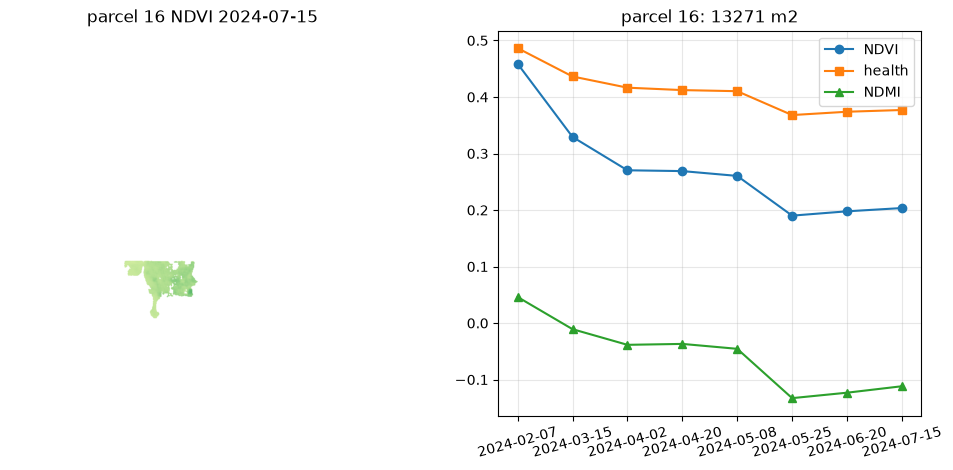

parcel 16: area 13271 m2 | NDVI 0.459 → 0.329 → 0.270 → 0.269 → 0.260 → 0.190 → 0.198 → 0.203 | health 0.486 → 0.436 → 0.416 → 0.412 → 0.410 → 0.368 → 0.374 → 0.377 | slope +0.006


In [11]:
def _show_parcel(pid):
    mk = parcels == pid
    ns = [float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES]
    hs = [float(np.nanmean(H[d][mk])) for d in DATES]
    ms = [float(np.nanmean(cube[d]['ndmi'][mk])) for d in DATES]
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(np.where(mk, cube[DATES[-1]]['ndvi'], np.nan), vmin=-0.2, vmax=0.9, cmap='YlGn')
    ax[0].set_title(f'parcel {pid} NDVI {DATES[-1]}'); ax[0].axis('off')
    ax[1].plot(DATES, ns, marker='o', label='NDVI'); ax[1].plot(DATES, hs, marker='s', label='health'); ax[1].plot(DATES, ms, marker='^', label='NDMI')
    ax[1].set_title(f"parcel {pid}: {mk.sum()} m2"); ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].tick_params(axis='x', rotation=15)
    plt.show()
    print(f"parcel {pid}: area {mk.sum()} m2 | NDVI {' → '.join(f'{v:.3f}' for v in ns)} | health {' → '.join(f'{v:.3f}' for v in hs)} | slope {ns[-1]-ns[-2]:+.3f}")
try:
    import ipywidgets as widgets
    from IPython.display import display
    _ids = list(range(1, int(parcels.max()) + 1)) if parcels is not None and parcels.max() > 0 else []
    _w_p = widgets.Dropdown(options=_ids, value=_ids[0] if _ids else None, description='Parcel:')
    _w_po = widgets.Output()
    def _updp(*a):
        _w_po.clear_output(wait=True)
        with _w_po: _show_parcel(int(_w_p.value))
    _w_p.observe(_updp, 'value')
    display(_w_p, _w_po)
    _updp()
except Exception as e:
    print('widgets unavailable:', e)
print('--- static default view (embedded for headless/nbviewer) ---')
_show_parcel(int(parcels.max() // 2) if parcels is not None and parcels.max() > 0 else 1)


### Index multi-select — overlay any batch indices


SelectMultiple(description='Indices:', index=(0, 8, 10), options=('ndvi', 'gndvi', 'ndre', 'evi2', 'savi', 'mt…

Output()

--- static default view (embedded for headless/nbviewer) ---


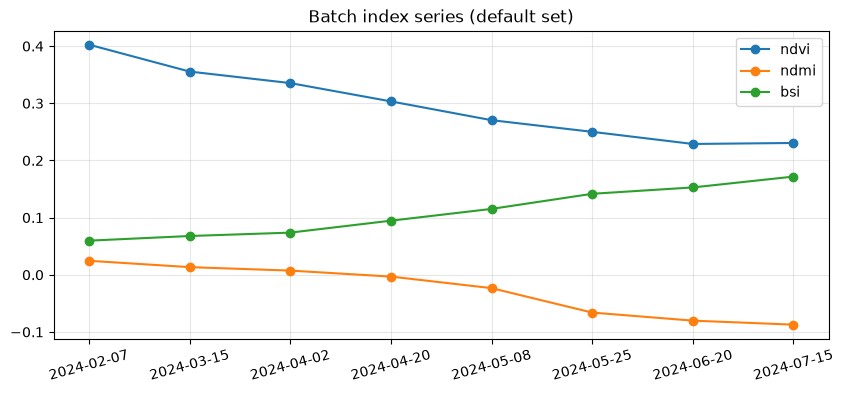

In [12]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    _w_m = widgets.SelectMultiple(options=ALL_IDX, value=('ndvi', 'ndmi', 'bsi'), description='Indices:')
    _w_mo = widgets.Output()
    def _updm(*a):
        _w_mo.clear_output(wait=True)
        with _w_mo:
            fig, ax = plt.subplots(figsize=(10, 4))
            for _n in _w_m.value:
                _y = [next(r['mean'] for r in rows if r['date'] == _d and r['index'] == _n) for _d in DATES]
                ax.plot(DATES, _y, marker='o', label=_n)
            ax.legend(ncol=6, fontsize=8); ax.grid(alpha=0.3); ax.tick_params(axis='x', rotation=15)
            ax.set_title('Batch index series (multi-select)');
            plt.show()
    _w_m.observe(_updm, 'value')
    display(_w_m, _w_mo)
    _updm()
except Exception as e:
    print('widgets unavailable:', e)
print('--- static default view (embedded for headless/nbviewer) ---')
fig, ax = plt.subplots(figsize=(10, 4))
for _n in ('ndvi', 'ndmi', 'bsi'):
    _y = [next(r['mean'] for r in rows if r['date'] == _d and r['index'] == _n) for _d in DATES]
    ax.plot(DATES, _y, marker='o', label=_n)
ax.legend(); ax.grid(alpha=0.3); ax.tick_params(axis='x', rotation=15)
ax.set_title('Batch index series (default set)'); plt.show()


## 9. QA inventory


In [13]:
from output_layout import product_inventory, format_inventory_record
tifs = sorted(BATCH.glob('*.tif'))
for rec in product_inventory(tifs): print(format_inventory_record(rec))
print('batch files:', sorted(p.name for p in BATCH.iterdir()))

batch_croptype.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=65a96884edaa3f77657ec0c5cae275d6d945d0cc4ea226f8661fc80c9aa1fec3
batch_dndvi.tif: 1024x1024, 1 bands float32, 1 m, compression=NONE, 4,197,753 bytes, sha256=eef66977f88c8d7daee6fc7a4a8bb2f084560dc82402f147aacb42df918e5cf4
batch_health.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=bdff5e37b6c6af22936ac5525a3fa8cac93da6785bcef098375070ae0ac1ad86
batch_kmeans.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=9449d7d9b2defeeeba90e0f5ad1dcefcb60b36d9d31ef3d54b9caba7fc1e9223
batch_slope.tif: 1024x1024, 1 bands float32, 1 m, compression=NONE, 4,197,753 bytes, sha256=64c59fe739385838d94d3a827e40379e613f295946c167bd5779320b637ad8ed
batch_vigor.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=e68e977cbb633462eab52d8458871c46b1094b15945c33eba9659a7e034ab967
batch files: ['BATCH_REPORT.md', 'CROP_DOSSIER.csv', 'INTELLI